In [20]:
import pandas as pd

caminho = r"..\data\raw\PETR4.csv"

def carregar_dados(caminho_csv):
    """Carrega os dados históricos e garante a ordenação cronológica."""
    df = pd.read_csv(caminho_csv, parse_dates=True, index_col=0)
    df = df.sort_index()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    return df

In [21]:
def calcular_medias_moveis(df):
    """Calcula as médias móveis aritméticas de 11 e 40 períodos

    baseadas no Fechamento Ajustado (Adj Close).
    """
    print("Calculando indicadores...")

    # Média Móvel Simples (SMA) de 11 períodos
    df["MA_11"] = df["Close"].rolling(window=11).mean()

    # Média Móvel Simples (SMA) de 40 períodos
    df["MA_40"] = df["Close"].rolling(window=40).mean()

    return df

In [25]:
# --- Execução do Projeto ---
if __name__ == "__main__":
    arquivo = r"..\data\raw\PETR4.csv"

    # 1. Carregar
    df_projeto = carregar_dados(arquivo)

    # 2. Calcular Indicadores
    df_projeto = calcular_medias_moveis(df_projeto)

    # Visualizando o resultado final com as novas colunas
    print("\n--- DataFrame Atualizado (Últimos dias) ---")
    colunas_historico = ["Close", "High", "Low", "Open", "Volume", "MA_11", "MA_40"]
    print(df_projeto[colunas_historico].tail(10))

    # Opcional: Verificar as primeiras linhas para notar o efeito do "Warm-up"
    print("\n--- DataFrame Atualizado (Primeiros dias) ---")
    print(df_projeto[colunas_historico].head(15))

Calculando indicadores...

--- DataFrame Atualizado (Últimos dias) ---
                Close       High        Low       Open    Volume      MA_11  \
Date                                                                          
2025-12-15  29.813650  30.001748  29.710195  29.794840  31898900  29.948739   
2025-12-16  28.910774  29.653765  28.788511  29.653765  52661900  29.853835   
2025-12-17  29.230543  29.230543  28.986015  29.023635  39337100  29.769190   
2025-12-18  29.061255  29.418643  28.995420  29.343404  34311000  29.648636   
2025-12-19  29.164709  29.381022  29.127088  29.221138  45807700  29.519532   
2025-12-22  29.249353  29.653766  29.249353  29.390427  35896900  29.496447   
2025-12-23  29.406649  29.658900  29.299928  29.639496  35703900  29.462867   
2025-12-26  29.503668  29.523072  29.222312  29.406648  20178600  29.421006   
2025-12-29  29.814131  29.891746  29.610390  29.649197  20588100  29.400530   
2025-12-30  29.901449  30.037276  29.736516  29.882045  1688

In [27]:
import numpy as np


def gerar_sinais_cruzamento(df):
    """Gera sinais de compra (1) e venda (-1) baseados no cruzamento

    da MA_11 com a MA_40.
    """
    print("Gerando sinais de trading...")

    # 1. Identificar a posição da média curta em relação à longa
    # Se MA_11 > MA_40 -> True (1), senão False (0)
    df["Posicao"] = df["MA_11"] > df["MA_40"]

    # 2. O cruzamento acontece quando a "Posicao" muda de ontem para hoje.
    # O .diff() calcula a diferença entre a linha atual e a anterior.
    # True (1) - False (0) = 1  -> Cruzou para cima (Compra)
    # False (0) - True (1) = -1 -> Cruzou para baixo (Venda)
    df["Sinal"] = df["Posicao"].astype(int).diff()

    # Como o primeiro elemento não tem anterior, o Pandas gera um NaN. Vamos limpá-lo.
    df["Sinal"] = df["Sinal"].fillna(0).astype(int)

    # Limpar a coluna temporária 'Posicao' para manter o DataFrame limpo
    df = df.drop(columns=["Posicao"])

    return df


# --- Aplicando no seu projeto ---
# Supondo que seu df_projeto já possua as colunas 'MA_11' e 'MA_40'
df_projeto = gerar_sinais_cruzamento(df_projeto)

# Vamos filtrar para ver apenas os dias em que o sinal foi gerado
dias_com_sinal = df_projeto[df_projeto["Sinal"] != 0]

print("\n--- Últimos Sinais Disparados pelo Modelo ---")
colunas_analise = ["Close", "MA_11", "MA_40", "Sinal"]
print(dias_com_sinal[colunas_analise].tail(10))

Gerando sinais de trading...

--- Últimos Sinais Disparados pelo Modelo ---
                Close      MA_11      MA_40  Sinal
Date                                              
2025-03-28  32.608448  31.943180  31.921518      1
2025-04-08  27.877914  31.435516  31.648184     -1
2025-05-28  28.058481  28.293836  28.257597      1
2025-06-06  27.285442  27.675635  27.675827     -1
2025-06-13  29.915585  27.862881  27.763695      1
2025-08-13  28.113111  29.226700  29.306561     -1
2025-09-05  28.769701  29.022780  28.949304      1
2025-10-13  28.431124  29.010810  29.172029     -1
2025-11-11  31.224392  29.035605  28.959916      1
2025-12-18  29.061255  29.648636  29.688329     -1


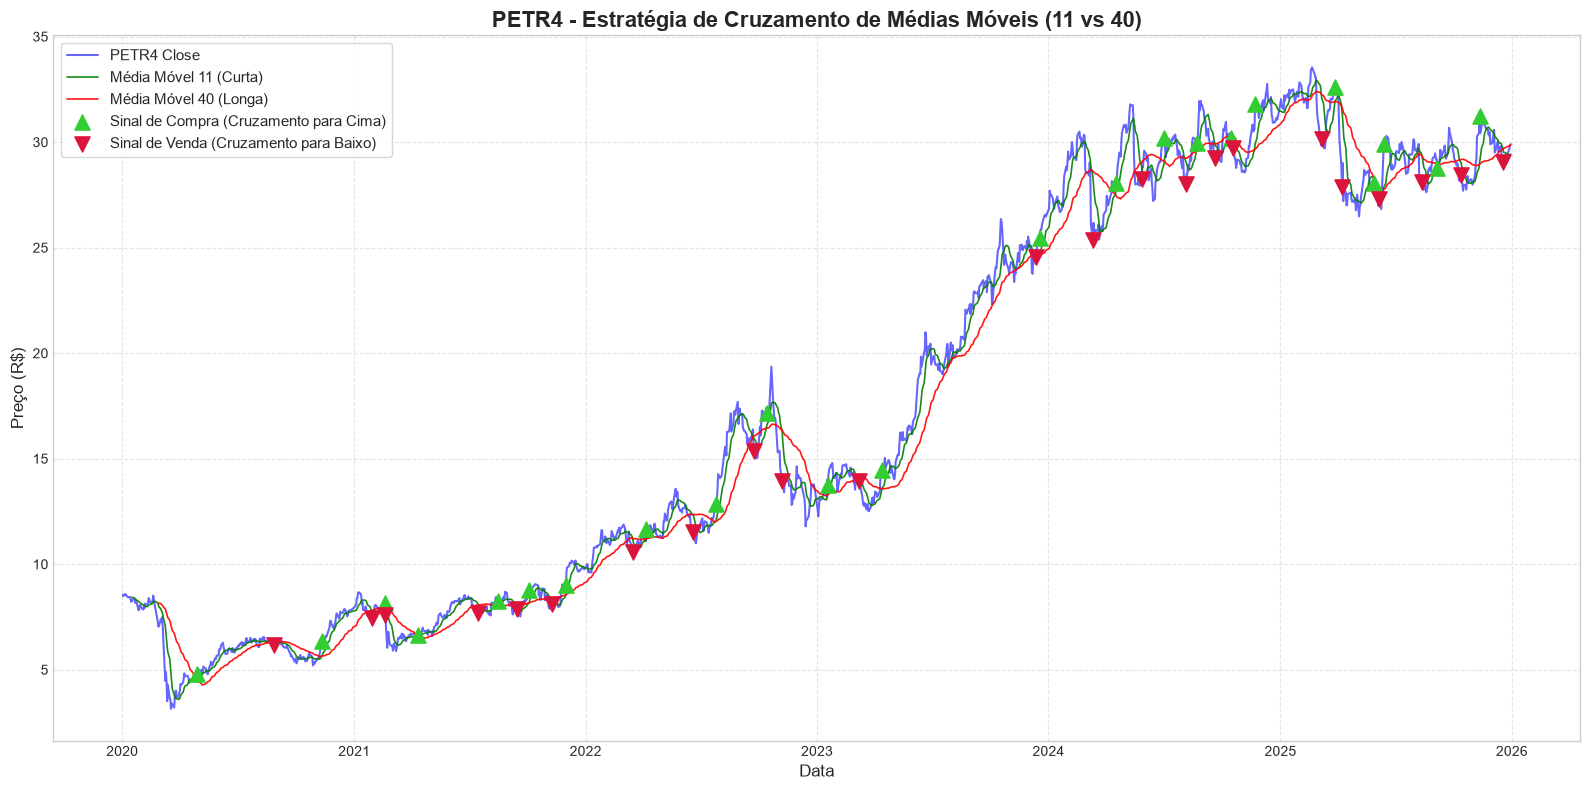

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Configurando o tamanho e estilo do gráfico
plt.figure(figsize=(16, 8))
plt.style.use("seaborn-v0_8-whitegrid")  # Estilo limpo e moderno

# 1. Plotar o Preço de Fechamento e as Médias Móveis
plt.plot(df_projeto.index, df_projeto["Close"], label="PETR4 Close", color="blue", alpha=0.6, linewidth=1.5)
plt.plot(df_projeto.index, df_projeto["MA_11"], label="Média Móvel 11 (Curta)", color="green", alpha=0.9, linewidth=1.2)
plt.plot(df_projeto.index, df_projeto["MA_40"], label="Média Móvel 40 (Longa)", color="red", alpha=0.9, linewidth=1.2)

# 2. Identificar e Plotar os Sinais de Compra (Seta para cima)
compras = df_projeto[df_projeto["Sinal"] == 1]
plt.scatter(
    compras.index,
    compras["Close"],
    marker="^",
    color="limegreen",
    s=120,
    label="Sinal de Compra (Cruzamento para Cima)",
    zorder=5,
)

# 3. Identificar e Plotar os Sinais de Venda (Seta para baixo)
vendas = df_projeto[df_projeto["Sinal"] == -1]
plt.scatter(
    vendas.index,
    vendas["Close"],
    marker="v",
    color="crimson",
    s=120,
    label="Sinal de Venda (Cruzamento para Baixo)",
    zorder=5,
)

# Customizações de títulos e eixos
plt.title("PETR4 - Estratégia de Cruzamento de Médias Móveis (11 vs 40)", fontsize=16, fontweight="bold")
plt.xlabel("Data", fontsize=12)
plt.ylabel("Preço (R$)", fontsize=12)
plt.legend(loc="upper left", fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

# Ajusta o layout para não cortar nenhuma informação
plt.tight_layout()

# Exibir o gráfico na tela
plt.show()

In [34]:
#import pandas as pd


def simular_operacoes_compra(df):
    """Simula operações apenas de compra (Long-Only).

    Entra em Sinal == 1 e encerra em Sinal == -1.
    Calcula o lucro/prejuízo de cada operação individual.
    """
    print("Simulando operações de compra...")

    lista_trades = []
    posicionado = False
    data_entrada = None
    preco_entrada = 0

    # Vamos iterar pelas linhas do DataFrame
    for data, linha in df.iterrows():
        sinal = linha["Sinal"]
        preco_fechamento = linha["Close"]

        # Condição 1: Gatilho de Compra (Início da Operação)
        if sinal == 1 and not posicionado:
            data_entrada = data
            preco_entrada = preco_fechamento
            posicionado = True

        # Condição 2: Gatilho de Venda (Fim da Operação)
        elif sinal == -1 and posicionado:
            data_saida = data
            preco_saida = preco_fechamento

            # Cálculos de Retorno
            retorno_percentual = ((preco_saida - preco_entrada) / preco_entrada) * 100
            lucro_prejuizo = preco_saida - preco_entrada

            # Guardando os dados do trade realizado
            lista_trades.append(
                {
                    "Data Entrada": data_entrada.date() if hasattr(data_entrada, "date") else data_entrada,
                    "Preço Entrada": round(preco_entrada, 2),
                    "Data Saída": data_saida.date() if hasattr(data_saida, "date") else data_saida,
                    "Preço Saída": round(preco_saida, 2),
                    "Resultado (R$)": round(lucro_prejuizo, 2),
                    "Retorno (%)": round(retorno_percentual, 2),
                }
            )

            # Reseta o status para a próxima operação
            posicionado = False
            data_entrada = None
            preco_entrada = 0

    # Converte a lista de dicionários em um novo DataFrame focado nos trades
    df_trades = pd.DataFrame(lista_trades)
    return df_trades


# --- Executando no projeto ---
# Supondo que df_projeto já tem as colunas 'Close' e 'Sinal'
df_resultado_trades = simular_operacoes_compra(df_projeto)

# Exibindo o resultado das operações
print(f"\n--- Total de Operações Realizadas: {len(df_resultado_trades)} ---")
print("\nÚltimas 10 operações realizadas:")
print(df_resultado_trades.tail(40))

# --- Estatísticas Básicas de Desempenho ---
if not df_resultado_trades.empty:
    operacoes_lucrativas = df_resultado_trades[df_resultado_trades["Retorno (%)"] > 0]
    taxa_acerto = (len(operacoes_lucrativas) / len(df_resultado_trades)) * 100

    print("\n================ RESUMO DO MODELO ================")
    print(f"Taxa de Acerto: {taxa_acerto:.2f}%")
    print(f"Maior Lucro: {df_resultado_trades['Retorno (%)'].max()}%")
    print(f"Maior Prejuízo: {df_resultado_trades['Retorno (%)'].min()}%")
    print(f"Retorno Médio por Trade: {df_resultado_trades['Retorno (%)'].mean():.2f}%")
    print("==================================================")

Simulando operações de compra...

--- Total de Operações Realizadas: 23 ---

Últimas 10 operações realizadas:
   Data Entrada  Preço Entrada  Data Saída  Preço Saída  Resultado (R$)  \
0    2020-04-28           4.81  2020-08-27         6.17            1.37   
1    2020-11-11           6.37  2021-01-29         7.44            1.06   
2    2021-02-18           8.16  2021-02-19         7.61           -0.54   
3    2021-04-12           6.66  2021-07-16         7.68            1.03   
4    2021-08-16           8.25  2021-09-14         7.90           -0.35   
5    2021-10-04           8.79  2021-11-09         8.13           -0.66   
6    2021-12-01           9.03  2022-03-16        10.57            1.54   
7    2022-04-07          11.67  2022-06-20        11.54           -0.13   
8    2022-07-25          12.83  2022-09-23        15.37            2.54   
9    2022-10-14          17.15  2022-11-07        13.93           -3.22   
10   2023-01-18          13.76  2023-03-08        13.96          

In [ ]:
import pandas as pd


def simular_operacoes_alvo_fixo(df, stop_loss_val=5.0, take_profit_val=10.0):
    """Simula operações de compra com Stop Loss e Take Profit fixos em Reais.

    Entra quando Sinal == 1 e sai quando o High atinge o Profit ou o Low atinge
    o Stop.
    """
    print("Simulando operações com Stop Loss e Take Profit...")

    lista_trades = []
    posicionado = False
    data_entrada = None
    preco_entrada = 0

    for data, linha in df.iterrows():
        sinal = linha["Sinal"]
        preco_fechamento = linha["Close"]
        maxima_dia = linha["High"]
        minima_dia = linha["Low"]

        # 1. Condição de Entrada (Gatilho pelo Sinal de cruzamento)
        if sinal == 1 and not posicionado:
            data_entrada = data
            preco_entrada = preco_fechamento  # Entra no fechamento do sinal
            alvo_gain = preco_entrada + take_profit_val
            alvo_loss = preco_entrada - stop_loss_val
            posicionado = True
            continue  # Passa para o próximo dia para começar a monitorar a saída

        # 2. Condição de Saída (Monitorando a posição)
        if posicionado:
            atingiu_loss = minima_dia <= alvo_loss
            atingiu_gain = maxima_dia >= alvo_gain

            # Caso ocorra ambos no mesmo dia (cenário extremo de volatilidade),
            # adotamos uma postura conservadora assumindo o Stop Loss.
            if atingiu_loss and atingiu_gain:
                motivo_saida = "Stop Loss (Volatilidade)"
                preco_saida = alvo_loss
            elif atingiu_loss:
                motivo_saida = "Stop Loss"
                preco_saida = alvo_loss
            elif atingiu_gain:
                motivo_saida = "Take Profit"
                preco_saida = alvo_gain
            else:
                motivo_saida = None

            # Se disparou algum alvo, encerra o trade e registra
            if motivo_saida:
                retorno_percentual = ((preco_saida - preco_entrada) / preco_entrada) * 100
                lucro_prejuizo = preco_saida - preco_entrada

                lista_trades.append(
                    {
                        "Data Entrada": data_entrada.date() if hasattr(data_entrada, "date") else data_entrada,
                        "Preço Entrada": round(preco_entrada, 2),
                        "Data Saída": data.date() if hasattr(data, "date") else data,
                        "Preço Saída": round(preco_saida, 2),
                        "Resultado (R$)": round(lucro_prejuizo, 2),
                        "Retorno (%)": round(retorno_percentual, 2),
                        "Status": motivo_saida,
                    }
                )
                # Reseta para buscar a próxima compra
                posicionado = False

    df_trades = pd.DataFrame(lista_trades)
    return df_trades


# --- Executando a nova lógica no projeto ---
# Executa a simulação com os alvos de R$ 5 e R$ 10
df_resultado_alvos = simular_operacoes_alvo_fixo(df_projeto, stop_loss_val=1.0, take_profit_val=2.0)

# --- Exibindo o resumo e estatísticas do novo modelo ---
print(f"\n--- Total de Operações Realizadas: {len(df_resultado_alvos)} ---")

if not df_resultado_alvos.empty:
    operacoes_lucrativas = df_resultado_alvos[df_resultado_alvos["Resultado (R$)"] > 0]
    taxa_acerto = (len(operacoes_lucrativas) / len(df_resultado_alvos)) * 100

    print("\n================ RESUMO COM STOP/GAIN FIXO ================")
    print(f"Taxa de Acerto: {taxa_acerto:.2f}%")
    print(f"Total de Take Profit atingidos: {len(df_resultado_alvos[df_resultado_alvos['Status'] == 'Take Profit'])}")
    print(f"Total de Stop Loss atingidos: {len(df_resultado_alvos[df_resultado_alvos['Status'].str.contains('Stop Loss')])}")
    print(f"Retorno Médio por Trade: {df_resultado_alvos['Retorno (%)'].mean():.2f}%")
    print("===========================================================")

    # Exibe todas as operações usando a mesma lógica anterior
    print("\n--- Lista Completa de Operações Realizadas ---")
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(df_resultado_alvos)

Simulando operações com Stop Loss e Take Profit...

--- Total de Operações Realizadas: 19 ---

================ RESUMO COM STOP/GAIN FIXO ================
Taxa de Acerto: 52.63%
Total de Take Profit atingidos: 10
Total de Stop Loss atingidos: 9
Retorno Médio por Trade: 6.49%

--- Lista Completa de Operações Realizadas ---


,Data Entrada,Preço Entrada,Data Saída,Preço Saída,Resultado (R$),Retorno (%),Status
0,2020-04-28,4.81,2020-11-23,6.81,2.0,41.61,Take Profit
1,2021-02-18,8.16,2021-02-22,7.16,-1.0,-12.26,Stop Loss
2,2021-04-12,6.66,2021-08-27,8.66,2.0,30.05,Take Profit
3,2021-10-04,8.79,2022-01-14,10.79,2.0,22.77,Take Profit
4,2022-04-07,11.67,2022-07-29,13.67,2.0,17.14,Take Profit
5,2022-10-14,17.15,2022-10-21,19.15,2.0,11.66,Take Profit
6,2023-01-18,13.76,2023-03-15,12.76,-1.0,-7.26,Stop Loss
7,2023-04-14,14.44,2023-05-12,16.44,2.0,13.85,Take Profit
8,2023-12-18,25.48,2024-01-03,27.48,2.0,7.85,Take Profit
9,2024-04-16,28.07,2024-04-25,30.07,2.0,7.12,Take Profit


In [44]:
import pandas as pd


def simular_operacoes_venda_fixo(df, stop_loss_val=5.0, take_profit_val=10.0):
    """Simula operações apenas de VENDA (Short-Only) com Stop Loss e Take Profit fixos em Reais.

    Entra quando Sinal == -1 e sai quando o Low atinge o Profit ou o High atinge
    o Stop.
    """
    print("Simulando operações de VENDA com Stop Loss e Take Profit...")

    lista_trades = []
    posicionado = False
    data_entrada = None
    preco_entrada = 0

    for data, linha in df.iterrows():
        sinal = linha["Sinal"]
        preco_fechamento = linha["Close"]
        maxima_dia = linha["High"]
        minima_dia = linha["Low"]

        # 1. Condição de Entrada (Gatilho pelo Sinal -1 de cruzamento para baixo)
        if sinal == -1 and not posicionado:
            data_entrada = data
            preco_entrada = preco_fechamento  # Entra vendido no fechamento
            alvo_gain = preco_entrada - take_profit_val  # Ganha na queda
            alvo_loss = preco_entrada + stop_loss_val  # Perde na alta
            posicionado = True
            continue

        # 2. Condição de Saída (Monitorando a posição vendida)
        if posicionado:
            atingiu_loss = maxima_dia >= alvo_loss  # Subiu e bateu o stop
            atingiu_gain = minima_dia <= alvo_gain  # Caiu e bateu o alvo

            # Postura conservadora se ambos ocorrerem no mesmo dia
            if atingiu_loss and atingiu_gain:
                motivo_saida = "Stop Loss (Volatilidade)"
                preco_saida = alvo_loss
            elif atingiu_loss:
                motivo_saida = "Stop Loss"
                preco_saida = alvo_loss
            elif atingiu_gain:
                motivo_saida = "Take Profit"
                preco_saida = alvo_gain
            else:
                motivo_saida = None

            # Se disparou a saída, encerra e calcula o resultado da VENDA
            if motivo_saida:
                # Na venda, o lucro ocorre se o preço de saída for MENOR que o de entrada
                lucro_prejuizo = preco_entrada - preco_saida
                retorno_percentual = (lucro_prejuizo / preco_entrada) * 100

                lista_trades.append(
                    {
                        "Data Entrada": data_entrada.date() if hasattr(data_entrada, "date") else data_entrada,
                        "Preço Entrada": round(preco_entrada, 2),
                        "Data Saída": data.date() if hasattr(data, "date") else data,
                        "Preço Saída": round(preco_saida, 2),
                        "Resultado (R$)": round(lucro_prejuizo, 2),
                        "Retorno (%)": round(retorno_percentual, 2),
                        "Status": motivo_saida,
                    }
                )
                posicionado = False

    df_trades = pd.DataFrame(lista_trades)
    return df_trades


# --- Executando a lógica de Venda ---
df_resultado_venda = simular_operacoes_venda_fixo(df_projeto, stop_loss_val=1.0, take_profit_val=2.0)

# --- Exibindo o resumo e estatísticas ---
print(f"\n--- Total de Operações de Venda Realizadas: {len(df_resultado_venda)} ---")

if not df_resultado_venda.empty:
    operacoes_lucrativas = df_resultado_venda[df_resultado_venda["Resultado (R$)"] > 0]
    taxa_acerto = (len(operacoes_lucrativas) / len(df_resultado_venda)) * 100

    print("\n================ RESUMO DA ESTRATÉGIA DE VENDA ================")
    print(f"Taxa de Acerto: {taxa_acerto:.2f}%")
    print(f"Total de Take Profit atingidos: {len(df_resultado_venda[df_resultado_venda['Status'] == 'Take Profit'])}")
    print(f"Total de Stop Loss atingidos: {len(df_resultado_venda[df_resultado_venda['Status'].str.contains('Stop Loss')])}")
    print(f"Retorno Médio por Trade: {df_resultado_venda['Retorno (%)'].mean():.2f}%")
    print("===============================================================")

    # Exibe todas as operações de venda na tela
    print("\n--- Lista Completa de Operações (Venda) ---")
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(df_resultado_venda)

Simulando operações de VENDA com Stop Loss e Take Profit...

--- Total de Operações de Venda Realizadas: 21 ---

================ RESUMO DA ESTRATÉGIA DE VENDA ================
Taxa de Acerto: 4.76%
Total de Take Profit atingidos: 1
Total de Stop Loss atingidos: 20
Retorno Médio por Trade: -5.94%

--- Lista Completa de Operações (Venda) ---


,Data Entrada,Preço Entrada,Data Saída,Preço Saída,Resultado (R$),Retorno (%),Status
0,2020-08-27,6.17,2020-11-24,7.17,-1.0,-16.20,Stop Loss
1,2021-01-29,7.44,2021-02-18,8.44,-1.0,-13.45,Stop Loss
2,2021-02-19,7.61,2021-08-27,8.61,-1.0,-13.13,Stop Loss
3,2021-09-14,7.90,2021-10-05,8.90,-1.0,-12.66,Stop Loss
4,2021-11-09,8.13,2021-12-01,9.13,-1.0,-12.30,Stop Loss
5,2022-03-16,10.57,2022-04-01,11.57,-1.0,-9.46,Stop Loss
6,2022-06-20,11.54,2022-07-25,12.54,-1.0,-8.66,Stop Loss
7,2022-09-23,15.37,2022-10-03,16.37,-1.0,-6.51,Stop Loss
8,2022-11-07,13.93,2022-12-14,11.93,2.0,14.35,Take Profit
9,2023-03-08,13.96,2023-04-18,14.96,-1.0,-7.16,Stop Loss
